In [1]:
import cdsapi
import os
import time
from math import cos, radians
import numpy as np
import os
import pandas as pd

# this script is resumable for large downloads
# but you need to setup your cdsapi key first
# nano $HOME/.cdsapirc or nano ~/.cdsapirc

# ADS account:
tjdu323@gmail.com
url: https://ads.atmosphere.copernicus.eu/api
key: 4045ee2c-02ad-45a0-a02a-57c79c038421

# ADS 2 account:
td323@ic.ac.uk
url: https://ads.atmosphere.copernicus.eu/api
key: 66646d71-95a1-482a-900e-09d67eb18385

## ADS 3 account 
tianjdu@polyu.edu.hk
url: https://ads.atmosphere.copernicus.eu/api
key: 807b30a4-26d8-4e40-afc0-904bd9d6a0aa

## ADS 4 account
tjdu@connect.ust.hk
url: https://ads.atmosphere.copernicus.eu/api
key: 74164cde-7818-4e96-88b5-1137eccb859c

## ADS 5 account
dutianju@gmail.com
url: https://ads.atmosphere.copernicus.eu/api
key: 930a7e62-ba60-400d-97aa-09a24a5e5f1a


东经E：113.815684~114.499703， 北纬N：22.134935~22.566546​

central location:114.1576935, 22.3507405​

In [2]:

vec = pd.read_csv("sub2_lon_lat_vectors.csv")

lon_sub2 = vec["longitude_50"].values
lat_sub2 = vec["latitude_50"].values

In [3]:
lat_sub2

array([22.86    , 22.84    , 22.82    , 22.8     , 22.780003, 22.760002,
       22.740002, 22.720001, 22.7     , 22.68    , 22.66    , 22.64    ,
       22.619999, 22.600002, 22.580002, 22.560001, 22.54    , 22.52    ,
       22.5     , 22.48    , 22.46    , 22.440002, 22.420002, 22.400002,
       22.380001, 22.36    , 22.34    , 22.32    , 22.3     , 22.280003,
       22.260002, 22.240002, 22.220001, 22.2     , 22.18    , 22.16    ,
       22.14    , 22.120003, 22.100002, 22.080002, 22.060001, 22.04    ,
       22.02    , 22.      , 21.98    , 21.96    , 21.940002, 21.920002,
       21.900002, 21.880001])

In [4]:
# ---------------- 1. Generate 5-km grid over Hong Kong ----------------
lats = lat_sub2
lons = lon_sub2
points = [(round(lon, 4), round(lat, 4)) for lat in lats for lon in lons]

# ---------------- 2.  Constant request parts -------------------------
dataset   = "cams-solar-radiation-timeseries"
altitude  = ["0"]                                  # list!
date_span = ["2021-01-01/2024-12-31"]                  # list! ["2020-01-01/2025-06-19"]     
time_step = "15minute"
time_ref  = "universal_time"
sky_type  = "observed_cloud"                           # ALL-sky
fmt       = "csv"                               # underscore! csv_expert

# ---------------- 3.  ADS client and output folder -------------------
client  = cdsapi.Client()                              # uses ~/.cdsapirc
outdir  = "Data/CAMS/raw/2021-2024/"  # output folder
os.makedirs(outdir, exist_ok=True)

# ---------------- 4.  Loop over every grid point ---------------------
for lon, lat in points:
    target = f"{outdir}/{lon}_{lat}.csv"
    if os.path.exists(target):
        continue                                       # skip if done
    req = {
        "sky_type"      : sky_type,
        "location"      : {"longitude": lon, "latitude": lat},
        "altitude"      : altitude,
        "date"          : date_span,
        "time_step"     : time_step,
        "time_reference": time_ref,
        "format"        : fmt
    }
    try:
        print(f"→ {lon},{lat}")
        client.retrieve(dataset, req).download(target)
        time.sleep(2)                                  # be polite
    except Exception as e:
        print(f"✖ {lon},{lat}  {e}")
# 1500

2026-01-05 10:01:42,523 INFO [2025-12-03T00:00:00Z] To improve our CAMS service, we need to hear from you! Please complete this very short [survey]( https://confluence.ecmwf.int/x/CruBEQ/). Thank you.


In [5]:
def read_cams_radiation_csv(file_path, header_row=68):
    """
    Reads CAMS radiation CSV and also extracts latitude, longitude, and altitude
    from metadata in lines 12–14.
    """
    # Read the whole file
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Extract latitude, longitude, and altitude
    def extract_value(line):
        return float(line.split(':')[-1].strip())

    latitude = extract_value(lines[11])
    longitude = extract_value(lines[12])
    altitude = extract_value(lines[13])

    # Read actual header and data
    header_line = lines[header_row].strip()
    column_names = header_line.split(';')

    # Read data
    df = pd.read_csv(file_path, skiprows=header_row + 1, sep=';', names=column_names, encoding='utf-8')

    # Parse timestamp
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = df['timestamp'].str.split('/').str[0]
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # Attach metadata to DataFrame attributes
    df.attrs['latitude'] = latitude
    df.attrs['longitude'] = longitude
    df.attrs['altitude'] = altitude
    df['latitude'] = latitude
    df['longitude'] = longitude
    df['altitude'] = altitude
    
    return df

In [8]:
import os
notebook_dir = os.getcwd()  # 获取当前 notebook 所在目录
data_dir = "Data/CAMS/raw/2021-2024"
df = read_cams_radiation_csv(data_dir, header_row=42)



IsADirectoryError: [Errno 21] Is a directory: 'Data/CAMS/raw/2021-2024'

In [6]:
def read_cams_radiation_csv(file_path, header_row=42, mode='mean'):
    """
    Reads CAMS radiation CSV and returns downsampled hourly DataFrame.
    
    Args:
        file_path: Full path to the CSV file.
        header_row: Line number where actual headers start (default 68).
        mode: 'mean' for hourly average, 'instant' for only :00 timestamps.
        
    Returns:
        column_names (list), hourly DataFrame
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    def extract_value(line):
        return float(line.split(':')[-1].strip())

    latitude = extract_value(lines[11])
    longitude = extract_value(lines[12])
    altitude = extract_value(lines[13])

    header_line = lines[header_row].strip()
    column_names = header_line.split(';')

    df = pd.read_csv(file_path, skiprows=header_row + 1, sep=';', names=column_names, encoding='utf-8')
    df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
    df['timestamp'] = df['timestamp'].str.split('/').str[0]
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df.set_index('timestamp', inplace=True)

    if mode == 'mean':
        df = df.resample('1h').mean(numeric_only=True).dropna(how='all')
    elif mode == 'instant':
        df = df
    else:
        raise ValueError("Invalid mode: use 'mean' or 'instant'")

    df = df.reset_index()
    df['latitude'] = latitude
    df['longitude'] = longitude
    df['altitude'] = altitude
    df.attrs['latitude'] = latitude
    df.attrs['longitude'] = longitude
    df.attrs['altitude'] = altitude

    return column_names, df


In [7]:
def process_and_save_hourly_csvs(source_root, target_root, header_row=68, mode='mean'):
    """
    Walk through all CSVs in source_root, resample to hourly, and save to target_root.
    
    Args:
        source_root: Root folder with raw CSVs.
        target_root: Destination for hourly CSVs.
        header_row: Row where actual data headers begin.
        mode: 'mean' or 'instant'
    """
    for dirpath, _, filenames in os.walk(source_root):
        for filename in filenames:
            if not filename.lower().endswith('.csv'):
                continue

            source_path = os.path.join(dirpath, filename)
            rel_dir = os.path.relpath(dirpath, source_root)
            target_dir = os.path.join(target_root, rel_dir)
            os.makedirs(target_dir, exist_ok=True)

            new_filename = os.path.splitext(filename)[0] + f'_{mode}.csv'
            target_path = os.path.join(target_dir, new_filename)

            if os.path.exists(target_path):
                print(f"⏭️ Skipped (already exists): {target_path}")
                continue

            try:
                headers, df = read_cams_radiation_csv(source_path, header_row=header_row, mode=mode)

                with open(target_path, 'w', encoding='utf-8') as f:
                    f.write(';'.join(headers) + '\n')
                    df.to_csv(f, sep=';', index=False, header=False)

                print(f"✅ {mode.upper()} saved: {target_path}")
            except Exception as e:
                print(f"❌ Failed: {source_path} — {e}")


In [11]:
process_and_save_hourly_csvs(
    source_root='Data/CAMS/raw/2021-2024',
    target_root='Data/CAMS/2021-2024_15mins',
    header_row=42,
    mode='instant',
)

⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.44_21.98_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.16_22.58_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.22_22.12_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.22_22.06_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.3_21.96_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.34_22.86_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.16_22.64_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.1_22.8_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.62_22.84_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.0_22.8_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./114.0_22.18_instant.csv
⏭️ Skipped (already exists): Data/CAMS/2021-2024_15mins/./113.74_21.96_instant.csv
⏭️ Skipped

In [1]:
import os
import pandas as pd

def check_hourly_time_range_consistency(root_folder, delimiter=';'):
    """
    Scans all hourly CSVs in a folder tree, extracts start/end timestamps,
    and checks whether their time coverage is consistent.

    Returns:
        consistent (list): List of (file_path, start_time, end_time)
        inconsistent (list): List of (file_path, start_time, end_time, reason)
    """
    time_ranges = []
    inconsistent = []
    ref_start, ref_end = None, None

    for dirpath, _, filenames in os.walk(root_folder):
        for filename in filenames:
            if not filename.lower().endswith('.csv'):
                continue
            path = os.path.join(dirpath, filename)
            try:
                df = pd.read_csv(path, sep=delimiter, usecols=[0], names=['timestamp'], header=0, parse_dates=['timestamp'])
                if df.empty:
                    inconsistent.append((path, None, None, 'Empty file'))
                    continue

                start = df['timestamp'].iloc[0]
                end = df['timestamp'].iloc[-1]

                if ref_start is None:
                    ref_start, ref_end = start, end
                    time_ranges.append((path, start, end))
                else:
                    if start != ref_start or end != ref_end:
                        inconsistent.append((path, start, end, 'Time range mismatch'))
                    else:
                        time_ranges.append((path, start, end))

            except Exception as e:
                inconsistent.append((path, None, None, f'Read error: {e}'))

    return time_ranges, inconsistent


In [ ]:
valid, mismatches = check_hourly_time_range_consistency('Data/CAMS/2021-2024_15mins')

print(f"✅ {len(valid)} files have consistent time ranges.")

if mismatches:
    print(f"❌ {len(mismatches)} inconsistent files found:")
    for path, start, end, reason in mismatches:
        print(f" - {path}: {start} → {end} | {reason}")


In [4]:
import pandas as pd

def read_cams_hourly_csv(file_path):
    # Read the file while fixing the header line and setting column names
    with open(file_path, 'r') as f:
        header_line = f.readline().lstrip('# ').strip()
        column_names = header_line.split(';') + ['latitude', 'longitude', 'altitude']

    # Read the data with corrected column names
    df = pd.read_csv(file_path, sep=';', skiprows=1, header=None, names=column_names)
    
    # Optional: parse the time column
    df['Observation period'] = pd.to_datetime(df['Observation period'])

    return df


In [5]:
import pandas as pd
import glob
import os

def read_cams_hourly_csv(file_path):
    # Read header line and build column names
    with open(file_path, 'r') as f:
        header_line = f.readline().lstrip('# ').strip()
        column_names = header_line.split(';') + ['latitude', 'longitude', 'altitude']

    # Load data
    df = pd.read_csv(file_path, sep=';', skiprows=43, header=None, names=column_names)

    # Parse timestamp
    df['Observation period'] = pd.to_datetime(df['Observation period'])

    return df


def merge_cams_folder(folder_path, output_file):
    # Find all CSVs in folder
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    if not csv_files:
        raise ValueError("No CSV files found in the folder.")

    # Read + collect all DataFrames
    frames = [read_cams_hourly_csv(f) for f in csv_files]

    # Concatenate
    merged_df = pd.concat(frames, ignore_index=True)

    # Sort by time if useful
    merged_df = merged_df.sort_values("Observation period")

    # Write output
    merged_df.to_csv(output_file, index=False)

    return merged_df


In [6]:
merged = merge_cams_folder("Data/CAMS/2021-2024_15mins", "merged_2021-2024.csv")
print(merged.head())


           Observation period  TOA  Clear sky GHI  Clear sky BHI  \
0         2021-01-01 10:30:00  0.0            0.0            0.0   
202188588 2021-01-01 10:30:00  0.0            0.0            0.0   
157460322 2021-01-01 10:30:00  0.0            0.0            0.0   
302722026 2021-01-01 10:30:00  0.0            0.0            0.0   
313798932 2021-01-01 10:30:00  0.0            0.0            0.0   

           Clear sky DHI  Clear sky BNI  GHI  BHI  DHI  BNI  Reliability  \
0                    0.0            0.0  0.0  0.0  0.0  0.0          1.0   
202188588            0.0            0.0  0.0  0.0  0.0  0.0          1.0   
157460322            0.0            0.0  0.0  0.0  0.0  0.0          1.0   
302722026            0.0            0.0  0.0  0.0  0.0  0.0          1.0   
313798932            0.0            0.0  0.0  0.0  0.0  0.0          1.0   

           latitude  longitude  altitude  
0             22.62     114.06       0.0  
202188588     22.76     113.92       0.0  
15746

In [12]:
def engineer_features(df):
    final_features = [
        'GHI',
        'Clear sky GHI',
        'Observation period',
        'longitude', 'latitude',
    ]
    return df, final_features


def build_grid_mapping(df):
    """
    Build row/col indices for grid based on lon/lat columns.
    Assumes df already has 'lon' and 'lat' (from read_cams_hourly_csv).
    """
    unique_coords = df[['longitude', 'latitude']].drop_duplicates()

    lons = sorted(unique_coords['longitude'].unique())
    # reverse=True so row 0 is the northernmost latitude, as before
    lats = sorted(unique_coords['latitude'].unique(), reverse=True)

    lon_to_idx = {lon: i for i, lon in enumerate(lons)}
    lat_to_idx = {lat: i for i, lat in enumerate(lats)}

    df['row'] = df['latitude'].map(lat_to_idx)
    df['col'] = df['longitude'].map(lon_to_idx)

    H, W = len(lats), len(lons)
    return df, (H, W)

In [13]:
df, final_features = engineer_features(merged)

In [14]:
df, grid_shape = build_grid_mapping(merged)
df_f = df[final_features + ['row', 'col']].copy()

In [17]:
df_f.head()

,GHI,Clear sky GHI,Observation period,longitude,latitude,row,col
0,0.0,0.0,2021-01-01 10:30:00,114.06,22.62,12,21
202188588,0.0,0.0,2021-01-01 10:30:00,113.92,22.76,5,14
157460322,0.0,0.0,2021-01-01 10:30:00,113.92,22.08,39,14
302722026,0.0,0.0,2021-01-01 10:30:00,113.76,22.32,27,6
313798932,0.0,0.0,2021-01-01 10:30:00,113.98,22.26,30,17


In [ ]:
merged = merged['Observation period','Clear sky GHI','GHI',]

,Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability,latitude,longitude,altitude
0,2021-01-01 10:30:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0,22.62,113.96,0.0
420642,2021-01-01 10:30:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0,21.96,113.74,0.0
2875658,2021-01-01 10:30:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0,22.58,113.70,0.0
560856,2021-01-01 10:30:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0,22.86,114.34,0.0
701070,2021-01-01 10:30:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0,22.06,114.22,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1402139,2024-12-31 23:45:00,60.4035,25.4167,7.9180,17.4987,45.6896,4.8037,0.0212,4.7825,0.1374,1.0,21.94,114.58,0.0
701069,2024-12-31 23:45:00,56.4632,23.6805,7.2856,16.3949,44.9102,6.8525,0.0362,6.8163,0.2185,1.0,22.86,114.34,0.0
841283,2024-12-31 23:45:00,58.2889,24.0797,7.3727,16.7069,44.0457,6.9399,0.0000,6.9399,0.0002,1.0,22.06,114.22,0.0
140213,2024-12-31 23:45:00,55.3414,22.4736,6.3936,16.0800,40.1779,9.3157,0.8473,8.4684,6.0481,1.0,22.62,113.96,0.0


In [18]:
import numpy as np
def csv_to_npz_grid(df=None,
                    csv_path=None,
                    out_path="out.npz",
                    grid_shape=(50, 50),
                    time_col="Observation period",
                    ghi_col="GHI",
                    ghi_clear_col="Clear sky GHI",
                    row_col="row",
                    col_col="col"):
    """
    Convert CSV or DataFrame to NPZ:
      data: (T, 3, H, W) with features [GHI, clear_sky_GHI]
      time: (T,) datetime64
    """

    # 1. Load CSV if df not given
    if df is None:
        if csv_path is None:
            raise ValueError("Must provide either df= or csv_path=")
        df = pd.read_csv(csv_path)

    H, W = grid_shape

    # 2. Ensure time column is datetime
    df[time_col] = pd.to_datetime(df[time_col])

    # 3. Build time axis
    times = np.sort(df[time_col].unique())
    T = len(times)
    time_index = {t: i for i, t in enumerate(times)}

    # 4. Allocate output array
    data = np.full((T, 2, H, W), np.nan, dtype=np.float32)

    # 5. Fill values using row[...] (NOT getattr)
    for _, row in df.iterrows():
        t = row[time_col]
        r = int(row[row_col])
        c = int(row[col_col])

        ti = time_index[t]

        data[ti, 0, r, c] = row[ghi_col]
        data[ti, 1, r, c] = row[ghi_clear_col]

    # 6. Save NPZ
    time_arr = times.astype("datetime64[ns]")
    np.savez(out_path, data=data, time=time_arr)

    return data, time_arr


In [19]:
data, time_arr = csv_to_npz_grid(
    df=df_f,
    out_path="ghi_grid2500_2ch_15mins.npz",
    grid_shape=(50, 50)
)

KeyboardInterrupt: 

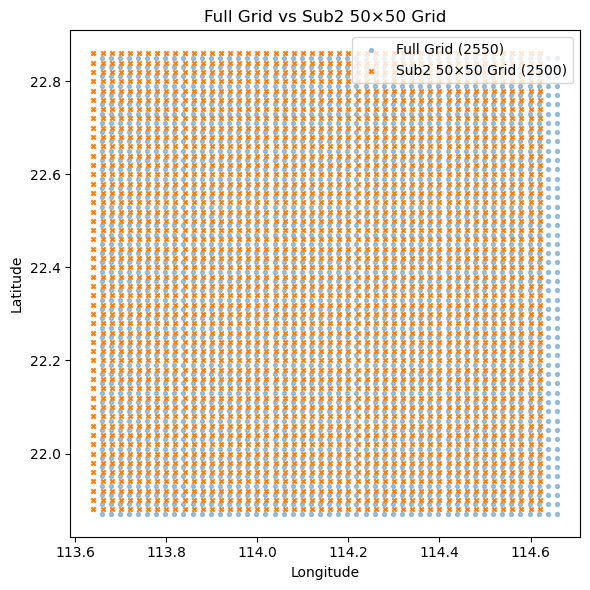

In [13]:
# 2550 points
points_df = pd.DataFrame(points, columns=['longitude', 'latitude'])

plt.figure(figsize=(6, 6))

plt.scatter(points_df['longitude'], points_df['latitude'],
            s=8, alpha=0.4, label='Full Grid (2550)')

plt.scatter(grid_sub2['longitude'], grid_sub2['latitude'],
            s=10, marker='x', label='Sub2 50×50 Grid (2500)')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.title("Full Grid vs Sub2 50×50 Grid")
plt.tight_layout()
plt.show()


In [27]:
# Merge and drop matching locations
merged_trimmed = (
    merged
    .merge(extra_points, on=['longitude', 'latitude'], how='left', indicator=True)
)

print("Rows before:", len(merged_trimmed))
merged_trimmed = merged_trimmed[merged_trimmed['_merge'] == 'left_only'].drop(columns=['_merge'])
print("Rows after:", len(merged_trimmed))


Rows before: 89413200
Rows after: 87660000


In [28]:
merged_trimmed.to_csv("merged_trimmed_2500_locations.csv", index=False)

In [ ]:
merged_trimmed.

,Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability,latitude,longitude,altitude
0,2021-01-01 00:00:00,395.7591,251.2143,169.1340,82.0803,589.3714,251.2143,169.1340,82.0803,589.3714,1.0000,22.7907,114.0977,0.0
1,2021-01-01 00:00:00,408.4518,254.4009,168.3395,86.0614,568.3642,225.5645,129.4901,96.0744,436.5079,1.0000,22.0507,114.2577,0.0
2,2021-01-01 00:00:00,403.2047,248.3041,162.4524,85.8517,555.2281,248.3041,162.4524,85.8517,555.2281,1.0000,21.9307,113.8777,0.0
3,2021-01-01 00:00:00,388.0647,244.3260,162.3585,81.9675,576.1869,244.3260,162.3585,81.9675,576.1869,1.0000,22.8307,113.6977,0.0
4,2021-01-01 00:00:00,402.3233,253.3739,169.1918,84.1821,580.1134,253.3739,169.1918,84.1821,580.1134,1.0000,22.3507,114.1377,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89413195,2024-12-31 23:00:00,119.7866,43.8826,10.9182,32.9644,80.0531,15.1639,0.0302,15.1337,0.3636,0.8333,22.5507,114.3577,0.0
89413196,2024-12-31 23:00:00,112.4362,39.4529,8.1916,31.2613,61.5010,7.2651,0.0000,7.2651,0.0000,0.7667,22.0907,113.6777,0.0
89413197,2024-12-31 23:00:00,111.3881,39.0479,8.2905,30.7574,62.6332,6.3139,0.0134,6.3004,0.0770,0.7667,22.2707,113.7177,0.0
89413198,2024-12-31 23:00:00,122.1489,45.1760,11.3457,33.8303,82.2746,24.6495,1.7893,22.8602,21.1406,0.8333,22.3507,114.3777,0.0
